# 🧹 Pandas Data Cleaning & EDA

**Goal:** take a messy sales dataset, clean it step by step, then explore it.

> 💡 Real-world data is always messy. Before any analysis or ML model, you must clean it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## Step 1: Load the data and take a first look

Always inspect first: `head()` shows sample rows, `info()` reveals missing values **and** wrong data types.

In [2]:
df = pd.read_csv("data/sales_data.csv")

print("=== First 5 rows ===")
print(df.head())
print("\n=== Shape (rows, columns):", df.shape)
print("\n=== Info (check missing values + dtypes) ===")
df.info()

=== First 5 rows ===
   OrderID        Date       City   Product  Quantity     Price Salesperson
0     1001  2026-01-05     Lahore    Laptop       2.0    150000       Ahmed
1     1002  2026-01-06    karachi     Mouse       5.0      2500        Sara
2     1003  2026-01-07     LAHORE  Keyboard       NaN      4500       Ahmed
3     1004  2026-01-08  Islamabad   Monitor       1.0  Rs.35000         NaN
4     1005  2026-01-09     Lahore    Laptop       1.0    150000       Ahmed

=== Shape (rows, columns): (20, 7)

=== Info (check missing values + dtypes) ===
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      20 non-null     int64  
 1   Date         20 non-null     str    
 2   City         19 non-null     str    
 3   Product      20 non-null     str    
 4   Quantity     18 non-null     float64
 5   Price        20 non-null     str    
 6   Salespers

## Step 2: Handle missing values

- **Quantity** (2 missing): fill with **median** — safer than mean, one huge order won't skew it.
- **City** (1 missing): we can't guess a city → drop that row.
- **Salesperson** (3 missing): label "Unknown" — dropping would lose real sales records.

In [3]:
print("=== Missing values per column ===")
print(df.isnull().sum())

df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df = df.dropna(subset=["City"])
df["Salesperson"] = df["Salesperson"].fillna("Unknown")

print("\n=== After handling ===")
print(df.isnull().sum())

=== Missing values per column ===
OrderID        0
Date           0
City           1
Product        0
Quantity       2
Price          0
Salesperson    3
dtype: int64

=== After handling ===
OrderID        0
Date           0
City           0
Product        0
Quantity       0
Price          0
Salesperson    0
dtype: int64


## Step 3: Remove duplicate rows

⚠️ OrderID **1002 appears twice** — the same order counted twice would inflate sales numbers!

In [4]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate row(s)")

Removed 1 duplicate row(s)


## Step 4: Fix inconsistent text (City column)

`"Lahore"`, `"lahore"`, `"LAHORE "` are the **same** city — but for `groupby()` they are 3 different groups!
Fix: `strip()` removes extra spaces, `title()` standardizes to `"Lahore"` format.

In [5]:
print("=== City values BEFORE ===")
print(df["City"].unique())

df["City"] = df["City"].str.strip().str.title()

print("\n=== City values AFTER ===")
print(df["City"].unique())

=== City values BEFORE ===
<StringArray>
[   'Lahore',   'karachi',    'LAHORE', 'Islamabad',  'Karachi ',    'lahore',
  'Peshawar',   'Karachi',   'LAHORE ',    'Quetta',  'peshawar',    'Multan']
Length: 12, dtype: str

=== City values AFTER ===
<StringArray>
['Lahore', 'Karachi', 'Islamabad', 'Peshawar', 'Quetta', 'Multan']
Length: 6, dtype: str


## Step 5: Fix wrong data types (Price column)

Some prices are `"Rs.35000"` (text) — math on text fails. Strip `"Rs."` and convert to numbers.
Also convert `Date` to datetime so we can analyze trends by month.

In [6]:
df["Price"] = (
    df["Price"].astype(str)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["Date"] = pd.to_datetime(df["Date"])
df["Revenue"] = df["Quantity"] * df["Price"]

print("=== Cleaned dtypes ===")
print(df.dtypes)

=== Cleaned dtypes ===
OrderID                 int64
Date           datetime64[us]
City                      str
Product                   str
Quantity              float64
Price                 float64
Salesperson               str
Revenue               float64
dtype: object


## Step 6: Explore the clean data (EDA)

Now the fun part — ask questions: which city earns most? Which product? Any monthly trend?

In [7]:
print("=== Summary stats ===")
print(df.describe())

print("\n=== Total revenue by city ===")
print(df.groupby("City")["Revenue"].sum().sort_values(ascending=False))

print("\n=== Total revenue by product ===")
print(df.groupby("Product")["Revenue"].sum().sort_values(ascending=False))

print("\n=== Monthly revenue trend ===")
print(df.set_index("Date").resample("ME")["Revenue"].sum())

=== Summary stats ===
           OrderID                 Date   Quantity          Price  \
count    18.000000                   18  18.000000      18.000000   
mean   1010.111111  2026-01-14 02:40:00   3.722222   42055.555556   
min    1001.000000  2026-01-05 00:00:00   1.000000    2500.000000   
25%    1005.250000  2026-01-09 06:00:00   2.000000    4500.000000   
50%    1010.500000  2026-01-14 12:00:00   3.000000    8000.000000   
75%    1014.750000  2026-01-18 18:00:00   5.000000   35000.000000   
max    1019.000000  2026-01-23 00:00:00  10.000000  150000.000000   
std       5.768973                  NaN   2.630266   60457.541954   

             Revenue  
count      18.000000  
mean    73750.000000  
min      7500.000000  
25%     15125.000000  
50%     33500.000000  
75%     90750.000000  
max    300000.000000  
std     93360.504623  

=== Total revenue by city ===
City
Lahore       569000.0
Islamabad    335000.0
Karachi      332500.0
Peshawar      39500.0
Quetta        31500.0
Mul

## Step 7: Visualize 📊

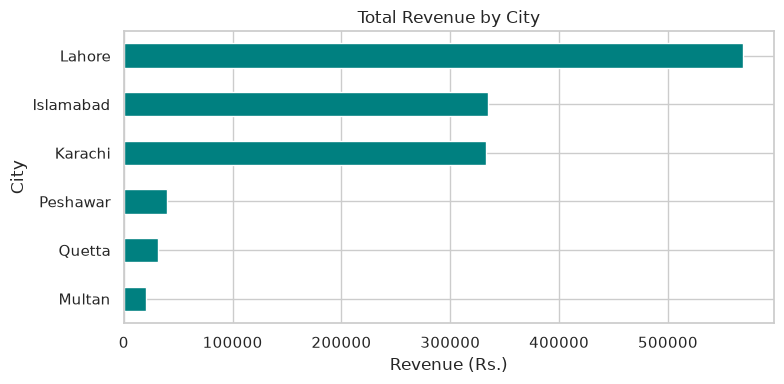

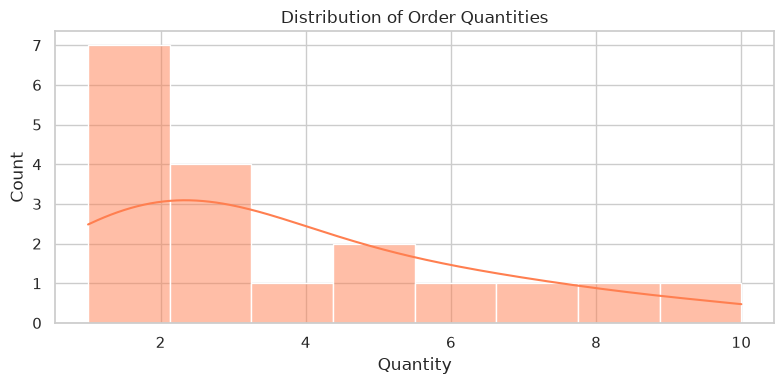

In [8]:
plt.figure(figsize=(8, 4))
df.groupby("City")["Revenue"].sum().sort_values().plot(kind="barh", color="teal")
plt.title("Total Revenue by City")
plt.xlabel("Revenue (Rs.)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df["Quantity"], bins=8, kde=True, color="coral")
plt.title("Distribution of Order Quantities")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()

## Step 8: Save the cleaned dataset ✅

Compare `data/sales_data.csv` (messy) vs `data/sales_data_cleaned.csv` (clean)!

In [9]:
df.to_csv("data/sales_data_cleaned.csv", index=False)
print("Saved: data/sales_data_cleaned.csv")
print("\nDone! 🎉")

Saved: data/sales_data_cleaned.csv

Done! 🎉
